# UCI HAR Dataset 기반 CBAM 분류

### 결과 분석
```
Test accuracy: 94.71%
```

CBAM 기반 모델은 UCI HAR 데이터셋에서 test accuracy 94.71%를 기록하였지만 CNN으로 추출된 feature에 channel attention과 temporal attention을 적용하여 활동 분류에 중요한 feature channel과 시간 구간을 함께 강조했기 때문으로 해석된다.

반면 sitting과 standing은 큰 움직임보다는 자세 방향, 중력 성분, 센서 축의 미세한 차이에서 구분된다. 그러나 두 활동은 시간 변화가 작고 feature 분포가 유사하기 때문에 channel attention과 temporal attention을 적용하더라도 완전히 구분하는 데에는 한계가 있었다.

따라서 CBAM은 중요한 채널과 시간 구간을 함께 반영하여 전체적으로 높은 성능을 보였지만 유사한 정적 활동을 더 명확히 구분하기 위해서는 자세 방향 정보나 센서 축 간 관계를 보완하는 추가 구조가 필요하다고 판단된다.

In [22]:
# 라이브러리 import
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, ReLU, MaxPooling1D,
    GlobalAveragePooling1D, GlobalMaxPooling1D,
    Dense, Dropout, Concatenate, GaussianNoise,
    Multiply, Reshape
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

In [23]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
# 경로 정의
DATASET_PATH = "/content/drive/MyDrive/UCI HAR Dataset/"

TRAIN = "train/"
TEST  = "test/"

INPUT_SIGNAL_TYPES = [
    "body_acc_x_", "body_acc_y_", "body_acc_z_",
    "body_gyro_x_", "body_gyro_y_", "body_gyro_z_",
    "total_acc_x_", "total_acc_y_", "total_acc_z_"
]

LABELS = [
    "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
    "SITTING", "STANDING", "LAYING"
]

In [25]:
# X 데이터 로드 함수
def load_X(X_signals_paths):
    X_signals = []
    for signal_type_path in X_signals_paths:
        signal_data = []
        with open(signal_type_path, 'r') as file:
            for row in file:
                row = row.replace('  ', ' ').strip().split(' ')
                row = [np.float32(x) for x in row]
                signal_data.append(row)
        X_signals.append(signal_data)

    X_signals = np.array(X_signals)
    # (9, samples, 128) -> (samples, 128, 9)
    return np.transpose(X_signals, (1, 2, 0))

In [26]:
# y 데이터 로드 함수
def load_y(y_path):
    y = []
    with open(y_path, 'r') as file:
        for row in file:
            y.append(int(row.strip()))
    y = np.array(y, dtype=np.int32)
    return y - 1  # 1~6 -> 0~5

In [27]:
# 데이터 로드
X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

X_train = load_X(X_train_signals_paths)
X_test  = load_X(X_test_signals_paths)
y_train = load_y(DATASET_PATH + TRAIN + "y_train.txt")
y_test  = load_y(DATASET_PATH + TEST  + "y_test.txt")

print("X_train shape:", X_train.shape)
print("X_test shape:",  X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:",  y_test.shape)

X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)
y_train shape: (7352,)
y_test shape: (2947,)


In [28]:
# 데이터 표준화
mean = X_train.mean(axis=(0, 1), keepdims=True)
std  = X_train.std(axis=(0, 1),  keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std

In [29]:
# One-hot 인코딩
y_train_onehot = tf.keras.utils.to_categorical(y_train, num_classes=6)
y_test_onehot  = tf.keras.utils.to_categorical(y_test,  num_classes=6)

print("y_train_onehot shape:", y_train_onehot.shape)
print("y_test_onehot shape:",  y_test_onehot.shape)

y_train_onehot shape: (7352, 6)
y_test_onehot shape: (2947, 6)


## CBAM (Convolutional Block Attention Module)

CBAM은 **채널 어텐션 -> 공간(시간) 어텐션**을 순서대로 적용하는 어텐션 구조

SE Block이 채널만 봤다면, CBAM은 **어떤 채널이 중요한가** 와 **어느 시간 구간이 중요한가** 를 둘 다 학습

---

### Step 1 : Channel Attention (채널 어텐션)

1. **특징 추출**: 입력된 특징 맵을 HxW 방향으로 **Max Pooling**과 **GAP(Global Average Pooling)**를 각각 수행

    ->채널의 핵심 정보와 전반적인 통계 정보를 동시에 추출

2. **공유 MLP 통과**: 추출된 두 벡터는 가중치를 공유하는 MLP(Shared MLP)를 통과

    -> **ReLU 함수**로 비선형성을 부여해 복잡한 채널 간의 관계를 학습

3. **스코어 생성**: MLP를 통과한 두 결과물을 원소별 합(Element-wise Sum)으로 결합

    -> **시그모이드(Sigmoid)** 함수를 거쳐 0과 1 사이의 확률값인 **채널 어텐션 스코어**를 도출

4. **최종 필터링(Scaling)**: 계산된 스코어 벡터를 원본 특징 맵에 채널별로 곱함

    -> 유의미한 채널은 강조되고, 불필요한 노이즈 채널은 억제되는 '특징 재교정(Feature Recalibration)'이 완성

SE Block과의 차이: SE는 AvgPool만 사용, CBAM은 **AvgPool + MaxPool** 둘 다 사용해 더 풍부한 채널 통계를 반영

---

### Step 2 : Spatial Attention (공간/시간 어텐션)

1. **채널 축 기준 정보 압축 (Channel Pooling)**

    -> 채널 정보를 하나로 모으기 위해 채널 축을 기준으로 **Max Pooling과 Average Pooling을 각각 수행**

2. **2채널 블록 형성 (Concatenation)**

    -> 추출된 두 개의 맵을 하나로 합쳐(Concat) **2xHxW 크기의 압축된 특징 블록**을 만듦
3. **공간적 연관성 학습 (Spatial Convolution)**

    -> 이 2채널 맵 위로 **7x7 크기의 대형 커널을 사용하는 컨볼루션 연산**을 진행

    -> 이때 **제로 패딩(Zero Padding)을 적용**하여 연산 후에도 가로·세로 해상도 **HxW**는 원본과 동일하게 유지하고, 채널 수만 1로 줄여 최종적인 공간 중요도 지도 **1xHxW**를 도출

4. **확률 변환 및 최종 적용 (Sigmoid & Scaling)**

    -> **시그모이드(Sigmoid)** 함수를 적용하여 각 픽셀 위치의 중요도를 **0과 1 사이의 중요도 점수**로 변환 (이 값이 높을수록 모델이 집중해야 할 핵심 사물의 위치임을 의미)

    -> **공간 어텐션 맵은 채널 어텐션을 거친 특징 맵에 원소별로 곱해줌**(Element-wise Multiplication)(**유의미한 영역은 강조하고 무의미한 배경은 억제**하는 공간적 재교정)

---

### CBAM 전체 흐름
Conv 출력 -> Channel Attention -> Spatial Attention -> 최종 출력

In [30]:
# Channel Attention 정의
def channel_attention(x, ratio=16):
    channels = x.shape[-1]
    reduction = max(channels // ratio, 1)

    # 시간 축 전체를 평균/최대로 압축 -> (batch, channels)
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)

    # 두 통계를 같은 MLP에 통과 (가중치 공유)
    shared_dense1 = Dense(reduction, activation='relu',    use_bias=False)
    shared_dense2 = Dense(channels,  activation=None,      use_bias=False)

    avg_out = shared_dense2(shared_dense1(avg_pool))
    max_out = shared_dense2(shared_dense1(max_pool))

    # 두 결과를 더한 뒤 sigmoid로 채널별 가중치 생성
    scale = tf.keras.activations.sigmoid(avg_out + max_out)  # (batch, channels)
    scale = Reshape((1, channels))(scale)                    # (batch, 1, channels)

    return Multiply()([x, scale])

In [31]:
# Spatial Attention 정의
def spatial_attention(x, kernel_size=7):
    # 채널 방향을 1×1 Conv로 압축 -> (batch, time, 1) 각각 학습
    avg_pool = Conv1D(1, kernel_size=1, use_bias=False)(x)
    max_pool = Conv1D(1, kernel_size=1, use_bias=False)(x)

    # 채널 방향으로 합침 -> (batch, time, 2)
    concat = Concatenate(axis=-1)([avg_pool, max_pool])

    # Conv1D로 시간 위치별 가중치 학습 -> (batch, time, 1)
    scale = Conv1D(1, kernel_size=kernel_size, padding='same',
                   activation='sigmoid', use_bias=False)(concat)

    return Multiply()([x, scale])

In [32]:
# CBAM Block 정의: 채널 어텐션 -> 공간 어텐션 순서로 적용
def cbam_block(x, ratio=16, kernel_size=7):
    x = channel_attention(x, ratio=ratio)
    x = spatial_attention(x, kernel_size=kernel_size)
    return x

## Conv-CBAM Block
두 번의 Conv 연산으로 시간 패턴을 추출한 뒤, CBAM으로 채널 -> 시간 어텐션을 순서대로 적용


In [33]:
# Conv-CBAM Block 정의
def conv_cbam_block(x, filters, kernel_size=3, pool=True, ratio=16, attn_kernel=7):
    # 첫 번째 Conv: 기본적인 시간 패턴 추출
    x = Conv1D(filters, kernel_size=kernel_size, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # 두 번째 Conv: 더 복잡한 특징 학습
    x = Conv1D(filters, kernel_size=kernel_size, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # CBAM: 채널 어텐션 -> 공간(시간) 어텐션
    x = cbam_block(x, ratio=ratio, kernel_size=attn_kernel)

    if pool:
        x = MaxPooling1D(pool_size=2)(x)

    return x

In [34]:
# CBAM 모델 정의
def build_cbam_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    # 약한 노이즈: 과적합 방지
    x = GaussianNoise(0.01)(inputs)

    # 단일 Conv로 초기 특징 추출
    x = Conv1D(64, kernel_size=5, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Conv-CBAM Blocks
    x = conv_cbam_block(x, filters=64,  kernel_size=3, pool=True,  ratio=16, attn_kernel=7)
    x = conv_cbam_block(x, filters=128, kernel_size=3, pool=True,  ratio=16, attn_kernel=7)
    x = conv_cbam_block(x, filters=128, kernel_size=5, pool=False, ratio=16, attn_kernel=7)

    # 평균 + 최대 pooling 병합
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)
    x = Concatenate()([avg_pool, max_pool])

    # 분류 헤드
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

In [35]:
# 모델 생성 및 컴파일
input_shape = (X_train.shape[1], X_train.shape[2])  # (128, 9)
num_classes = 6

model = build_cbam_model(input_shape, num_classes)

model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_1    │ (None, 128, 9)    │          0 │ input_layer_1[0]… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 128, 64)   │      2,880 │ gaussian_noise_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_18[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_7 (ReLU)      │ (None, 128, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 128, 64)   │     12,288 │ re_lu_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_19[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_8 (ReLU)      │ (None, 128, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 128, 64)   │     12,288 │ re_lu_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_20[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_9 (ReLU)      │ (None, 128, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ re_lu_9[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ re_lu_9[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 4)         │        256 │ global_average_p… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │        256 │ dense_9[0][0],    │
│                     │                   │            │ dense_9[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 64)        │          0 │ dense_10[0][0],   │
│                     │                   │            │ dense_10[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sigmoid_3 (Sigmoid) │ (None, 64)        │          0 │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 1, 64)     │          0 │ sigmoid_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_6          │ (None, 128, 64)   │          0 │ re_lu_9[0][0],    │
│ (Multiply)          │                   │            │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 314,672 (1.20 MB)

 Trainable params: 313,264 (1.20 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [36]:
# Callback 설정
callbacks = [
    ModelCheckpoint(
        "UCI_HAR_CBAM_best.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=10,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

In [37]:
# 모델 학습
history = model.fit(
    X_train, y_train_onehot,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.4964 - loss: 1.3840
Epoch 1: val_accuracy improved from None to 0.35350, saving model to UCI_HAR_CBAM_best.keras

Epoch 1: finished saving model to UCI_HAR_CBAM_best.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 28s 143ms/step - accuracy: 0.6813 - loss: 0.9715 - val_accuracy: 0.3535 - val_loss: 1.7176 - learning_rate: 3.0000e-04
Epoch 2/100
87/92 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9298 - loss: 0.3427
Epoch 2: val_accuracy improved from 0.35350 to 0.46363, saving model to UCI_HAR_CBAM_best.keras

Epoch 2: finished saving model to UCI_HAR_CBAM_best.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9391 - loss: 0.3086 - val_accuracy: 0.4636 - val_loss: 1.3648 - learning_rate: 3.0000e-04
Epoch 3/100
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9486 - loss: 0.2721
Epoch 3: val_accuracy improved from 0.46363 to 0.91298, saving model to UCI_HAR_CBAM_best.keras

Epoch 3: finished saving model to UCI_HAR_CBAM_bes

In [38]:
model = tf.keras.models.load_model("UCI_HAR_CBAM_best.keras")

In [39]:
# 학습 및 테스트 성능 평가
train_loss, train_acc = model.evaluate(X_train, y_train_onehot, verbose=0)
test_loss,  test_acc  = model.evaluate(X_test,  y_test_onehot,  verbose=0)

print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 99.25%
Training loss: 0.1477
Test accuracy: 94.71%
Test loss: 0.3067


In [40]:
# 예측 및 분류 리포트
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     0.9959    0.9839    0.9899       496
           1     0.9955    0.9342    0.9639       471
           2     0.9287    0.9929    0.9597       420
           3     0.9324    0.8147    0.8696       491
           4     0.8837    0.9568    0.9188       532
           5     0.9572    1.0000    0.9781       537

    accuracy                         0.9471      2947
   macro avg     0.9489    0.9471    0.9467      2947
weighted avg     0.9484    0.9471    0.9464      2947



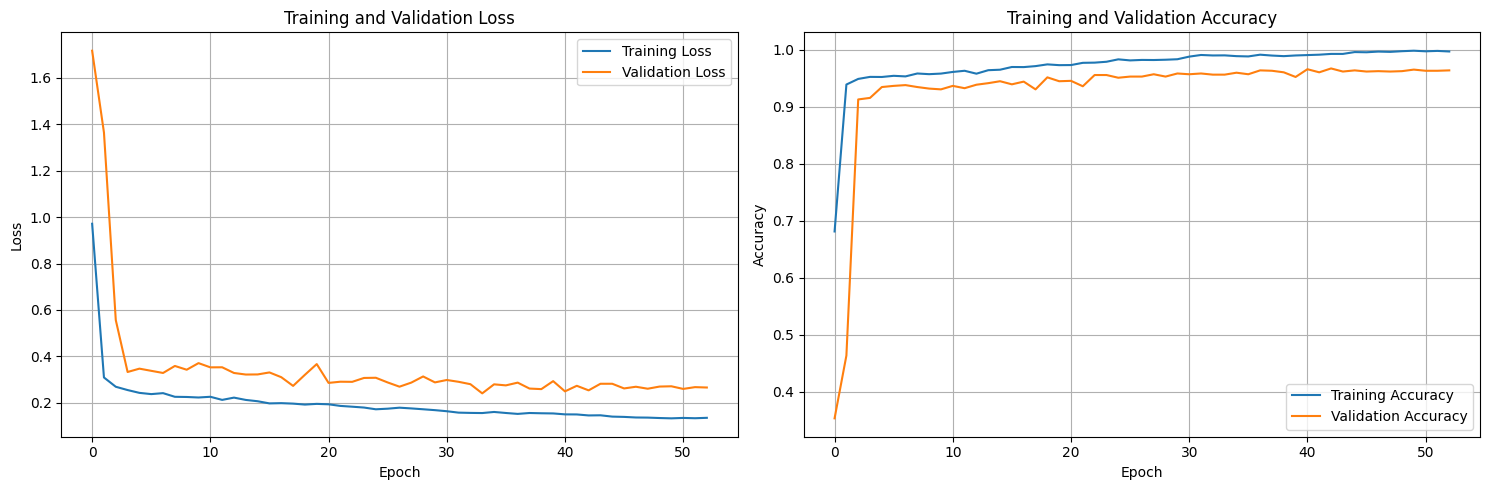

In [41]:
# 학습 곡선 시각화
train_loss_hist = history.history['loss']
val_loss_hist   = history.history['val_loss']
train_acc_hist  = history.history['accuracy']
val_acc_hist    = history.history['val_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_hist, label='Training Loss')
plt.plot(val_loss_hist,   label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_acc_hist, label='Training Accuracy')
plt.plot(val_acc_hist,   label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

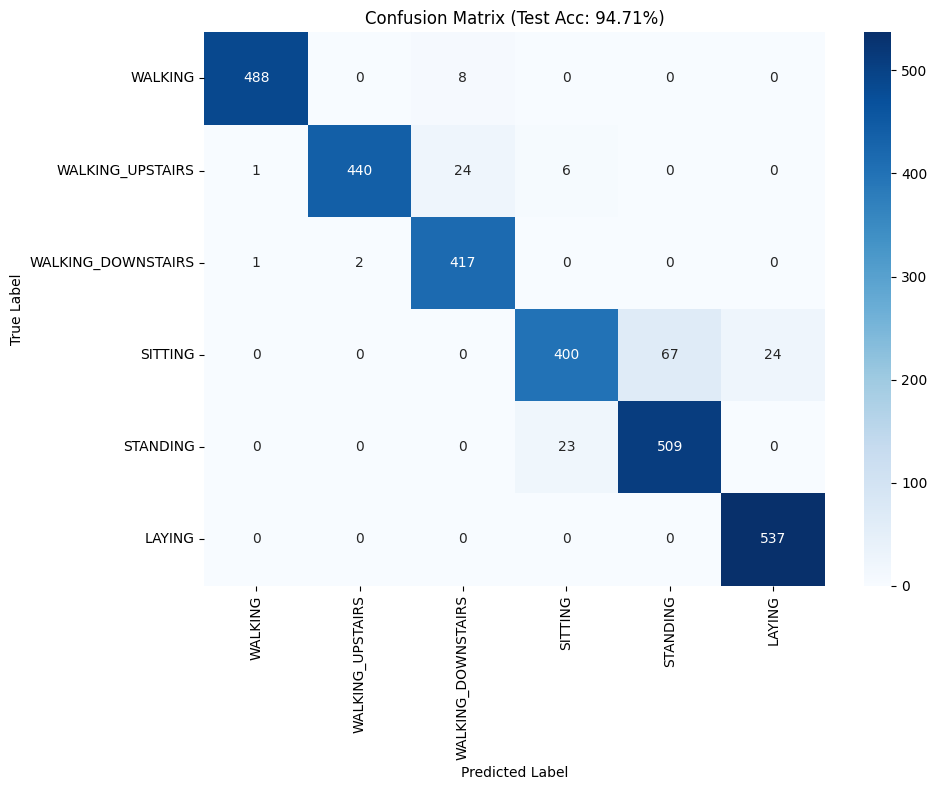

In [42]:
# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LABELS,
    yticklabels=LABELS
)
plt.title(f'Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()